#📌 Extracción

In [1]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Cargar datos desde la API
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json()

# Normalizar el JSON anidado
df = pd.json_normalize(data)

# Mostrar las primeras filas
df.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

### **Conoce el conjunto de datos**



In [2]:
print("Información general del DataFrame:")
df.info()

print("\nTipos de datos de cada columna:")
print(df.dtypes)

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.Tech

In [3]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Verificar si hay nulos introducidos por la conversión y rellenarlos con 0 o la media si es apropiado
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

print("Tipo de datos de 'account.Charges.Total' después de la conversión:")
print(df['account.Charges.Total'].dtype)

print("\nRegistros con account.Charges.Total igual a 0 después de la conversión:")
print(df[df['account.Charges.Total'] == 0].shape[0])

Tipo de datos de 'account.Charges.Total' después de la conversión:
float64

Registros con account.Charges.Total igual a 0 después de la conversión:
11


### **Comprobación de Incoherencias en los Datos y Manejo de inconsistencias**

In [5]:
# 1. Comprobar valores ausentes
print("\nValores nulos por columna:")
display(df.isnull().sum())

# 2. Comprobar filas duplicadas
num_duplicates = df.duplicated().sum()
print(f"\nNúmero de filas duplicadas: {num_duplicates}")

# 3. Comprobar inconsistencias en categorías (columnas tipo 'object')
print("\nValores únicos en columnas categóricas (object):")
for column in df.select_dtypes(include='object').columns:
    print(f"\nColumna '{column}': {df[column].unique()}")

# --- Corrección de Inconsistencias --- #

# Corregir la columna 'Churn': Reemplazar '' con 'No'
df['Churn'] = df['Churn'].replace('', 'No')

# Corregir inconsistencias en columnas de servicio (internet y teléfono)
columns_to_clean = [
    'phone.MultipleLines',
    'internet.OnlineSecurity',
    'internet.OnlineBackup',
    'internet.DeviceProtection',
    'internet.TechSupport',
    'internet.StreamingTV',
    'internet.StreamingMovies'
]

for col in columns_to_clean:
    if 'No internet service' in df[col].unique():
        df[col] = df[col].replace('No internet service', 'No')
    if 'No phone service' in df[col].unique():
        df[col] = df[col].replace('No phone service', 'No')

print("\n--- Inconsistencias corregidas. Verificando valores únicos de nuevo ---")
print("\nValores únicos en columnas categóricas (object) después de la corrección:")
for column in ['Churn'] + columns_to_clean:
    print(f"\nColumna '{column}': {df[column].unique()}")


Valores nulos por columna:


,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0



Número de filas duplicadas: 0

Valores únicos en columnas categóricas (object):

Columna 'customerID': ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Columna 'Churn': ['No' 'Yes' '']

Columna 'customer.gender': ['Female' 'Male']

Columna 'customer.Partner': ['Yes' 'No']

Columna 'customer.Dependents': ['Yes' 'No']

Columna 'phone.PhoneService': ['Yes' 'No']

Columna 'phone.MultipleLines': ['No' 'Yes' 'No phone service']

Columna 'internet.InternetService': ['DSL' 'Fiber optic' 'No']

Columna 'internet.OnlineSecurity': ['No' 'Yes' 'No internet service']

Columna 'internet.OnlineBackup': ['Yes' 'No' 'No internet service']

Columna 'internet.DeviceProtection': ['No' 'Yes' 'No internet service']

Columna 'internet.TechSupport': ['Yes' 'No' 'No internet service']

Columna 'internet.StreamingTV': ['Yes' 'No' 'No internet service']

Columna 'internet.StreamingMovies': ['No' 'Yes' 'No internet service']

Columna 'account.Contract': ['One year' 'Month-to-

### **Columna de Cuentas Diarias**

In [6]:
# Crear la columna 'Cuentas_Diarias' dividiendo los cargos mensuales por 30 (aproximación de días en un mes)
df['Cuentas_Diarias'] = df['account.Charges.Monthly'] / 30

print("Primeras 5 filas con la nueva columna 'Cuentas_Diarias':")
display(df[['account.Charges.Monthly', 'Cuentas_Diarias']].head())

Primeras 5 filas con la nueva columna 'Cuentas_Diarias':


,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


### **Estandarización y Transformación de Datos**

In [7]:
# Identificar columnas con valores binarios 'Yes'/'No'
binary_columns = [
    col for col in df.columns if df[col].nunique() == 2 and \
    ((df[col].isin(['Yes', 'No'])).all() or (df[col].isin([0, 1])).all())
]

# Excluir 'customer.SeniorCitizen' si ya está como 0/1
if 'customer.SeniorCitizen' in binary_columns:
    binary_columns.remove('customer.SeniorCitizen')

# Convertir 'Yes' a 1 y 'No' a 0 en las columnas identificadas
for col in binary_columns:
    if 'Yes' in df[col].unique() and 'No' in df[col].unique():
        df[col] = df[col].map({'Yes': 1, 'No': 0})

print("Columnas binarias convertidas (Yes=1, No=0):")
for col in binary_columns:
    print(f"  - {col}: {df[col].unique()}")

print("\nPrimeras 5 filas con las columnas transformadas:")
display(df[binary_columns].head())

Columnas binarias convertidas (Yes=1, No=0):
  - Churn: [0 1]
  - customer.Partner: [1 0]
  - customer.Dependents: [1 0]
  - phone.PhoneService: [1 0]
  - phone.MultipleLines: [0 1]
  - internet.OnlineSecurity: [0 1]
  - internet.OnlineBackup: [1 0]
  - internet.DeviceProtection: [0 1]
  - internet.TechSupport: [1 0]
  - internet.StreamingTV: [1 0]
  - internet.StreamingMovies: [0 1]
  - account.PaperlessBilling: [1 0]

Primeras 5 filas con las columnas transformadas:


,Churn,customer.Partner,customer.Dependents,phone.PhoneService,phone.MultipleLines,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.PaperlessBilling
0,0,1,1,1,0,0,1,0,1,1,0,1
1,0,0,0,1,1,0,0,0,0,0,1,0
2,1,0,0,1,0,0,0,1,0,0,0,1
3,1,1,0,1,0,0,1,1,0,1,1,1
4,1,1,0,1,0,0,0,0,1,1,0,1


#📊 Carga y análisis

### **Análisis Descriptivo**

In [8]:
# Generar estadísticas descriptivas para las columnas numéricas
print("Estadísticas descriptivas de las variables numéricas:")
display(df.describe())

# También podemos ver estadísticas para las columnas categóricas (object)
print("\nEstadísticas descriptivas de las variables categóricas:")
display(df.describe(include='object'))

Estadísticas descriptivas de las variables numéricas:


,Churn,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.257190,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2277.182035,2.157337
std,0.437115,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2268.648587,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,396.200000,1.180833
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1389.200000,2.343333
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3778.525000,2.995833
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333



Estadísticas descriptivas de las variables categóricas:


,customerID,customer.gender,internet.InternetService,account.Contract,account.PaymentMethod
count,7267,7267,7267,7267,7267
unique,7267,2,3,3,4
top,9995-HOTOH,Male,Fiber optic,Month-to-month,Electronic check
freq,1,3675,3198,4005,2445


### **Distribución de Evasión (Churn)**

/tmp/ipykernel_828/25279926.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, ax=ax[0], palette='viridis')


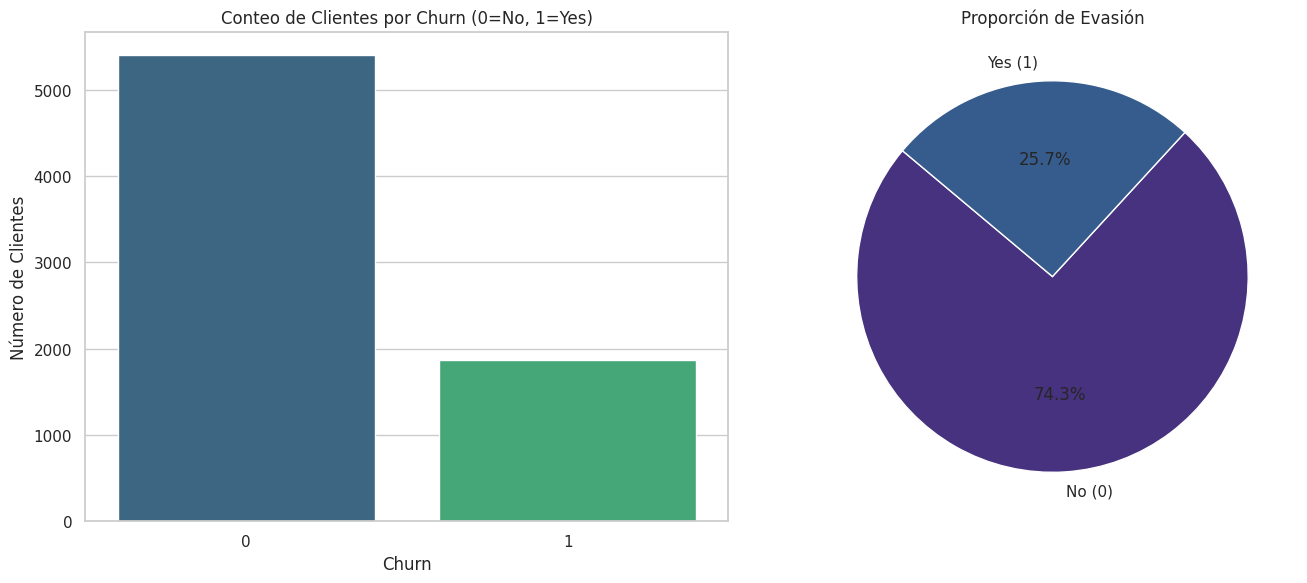

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# Crear la figura con dos subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico de barras (Conteo)
sns.countplot(x='Churn', data=df, ax=ax[0], palette='viridis')
ax[0].set_title('Conteo de Clientes por Churn (0=No, 1=Yes)')
ax[0].set_xlabel('Churn')
ax[0].set_ylabel('Número de Clientes')

# 2. Gráfico de pastel (Proporción)
churn_counts = df['Churn'].value_counts()
ax[1].pie(churn_counts, labels=['No (0)', 'Yes (1)'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis'))
ax[1].set_title('Proporción de Evasión')

plt.tight_layout()
plt.show()

## Identificar Variables Categóricas Clave



In [10]:
# Definir la lista de variables categóricas clave
key_categorical_vars = [
    'customer.gender',
    'account.Contract',
    'account.PaymentMethod',
    'internet.InternetService'
]

# Imprimir los valores únicos de cada columna seleccionada
print("Valores únicos en las variables categóricas clave:")
for col in key_categorical_vars:
    unique_values = df[col].unique()
    print(f"- {col}: {unique_values}")

# Confirmar que la lista está creada
print("\nLista 'key_categorical_vars' definida exitosamente.")

Valores únicos en las variables categóricas clave:
- customer.gender: ['Female' 'Male']
- account.Contract: ['One year' 'Month-to-month' 'Two year']
- account.PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
- internet.InternetService: ['DSL' 'Fiber optic' 'No']

Lista 'key_categorical_vars' definida exitosamente.


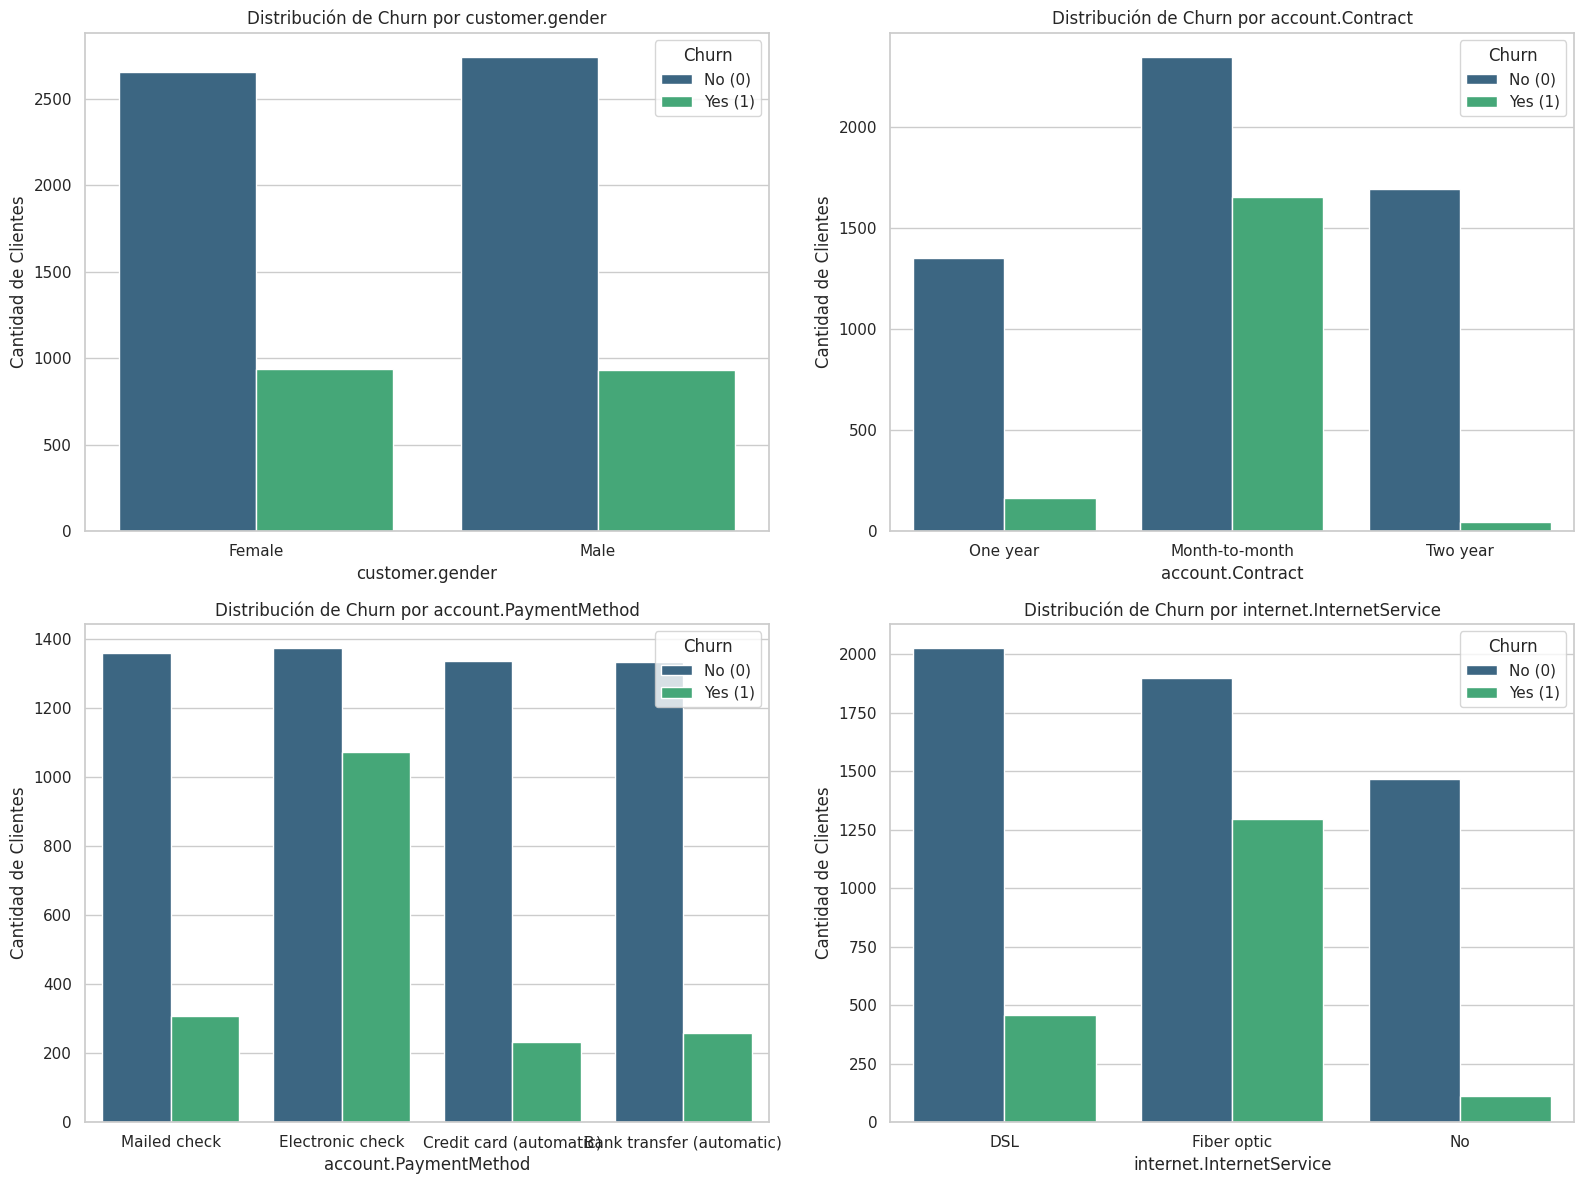

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de seaborn
sns.set_theme(style='whitegrid')

# Crear una figura con una cuadrícula de 2x2 subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

# Iterar sobre las variables categóricas clave y crear los countplots
for i, col in enumerate(key_categorical_vars):
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribución de Churn por {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Cantidad de Clientes')
    axes[i].legend(title='Churn', labels=['No (0)', 'Yes (1)'])

# Ajustar el diseño para evitar solapamientos
plt.tight_layout()
plt.show()

### **Conteo de evasión por variables numéricas**

In [12]:
# 1. Definir la lista de variables numéricas
numerical_vars = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']

# 2. Verificar los tipos de datos
print("Tipos de datos de las variables numéricas seleccionadas:")
print(df[numerical_vars].dtypes)

# 3. Validar estructura de datos con las primeras filas incluyendo Churn
print("\nVista previa de variables numéricas y Churn:")
display(df[numerical_vars + ['Churn']].head())


Tipos de datos de las variables numéricas seleccionadas:
customer.tenure              int64
account.Charges.Monthly    float64
account.Charges.Total      float64
dtype: object

Vista previa de variables numéricas y Churn:


,customer.tenure,account.Charges.Monthly,account.Charges.Total,Churn
0,9,65.6,593.30,0
1,9,59.9,542.40,0
2,4,73.9,280.85,1
3,13,98.0,1237.85,1
4,3,83.9,267.40,1


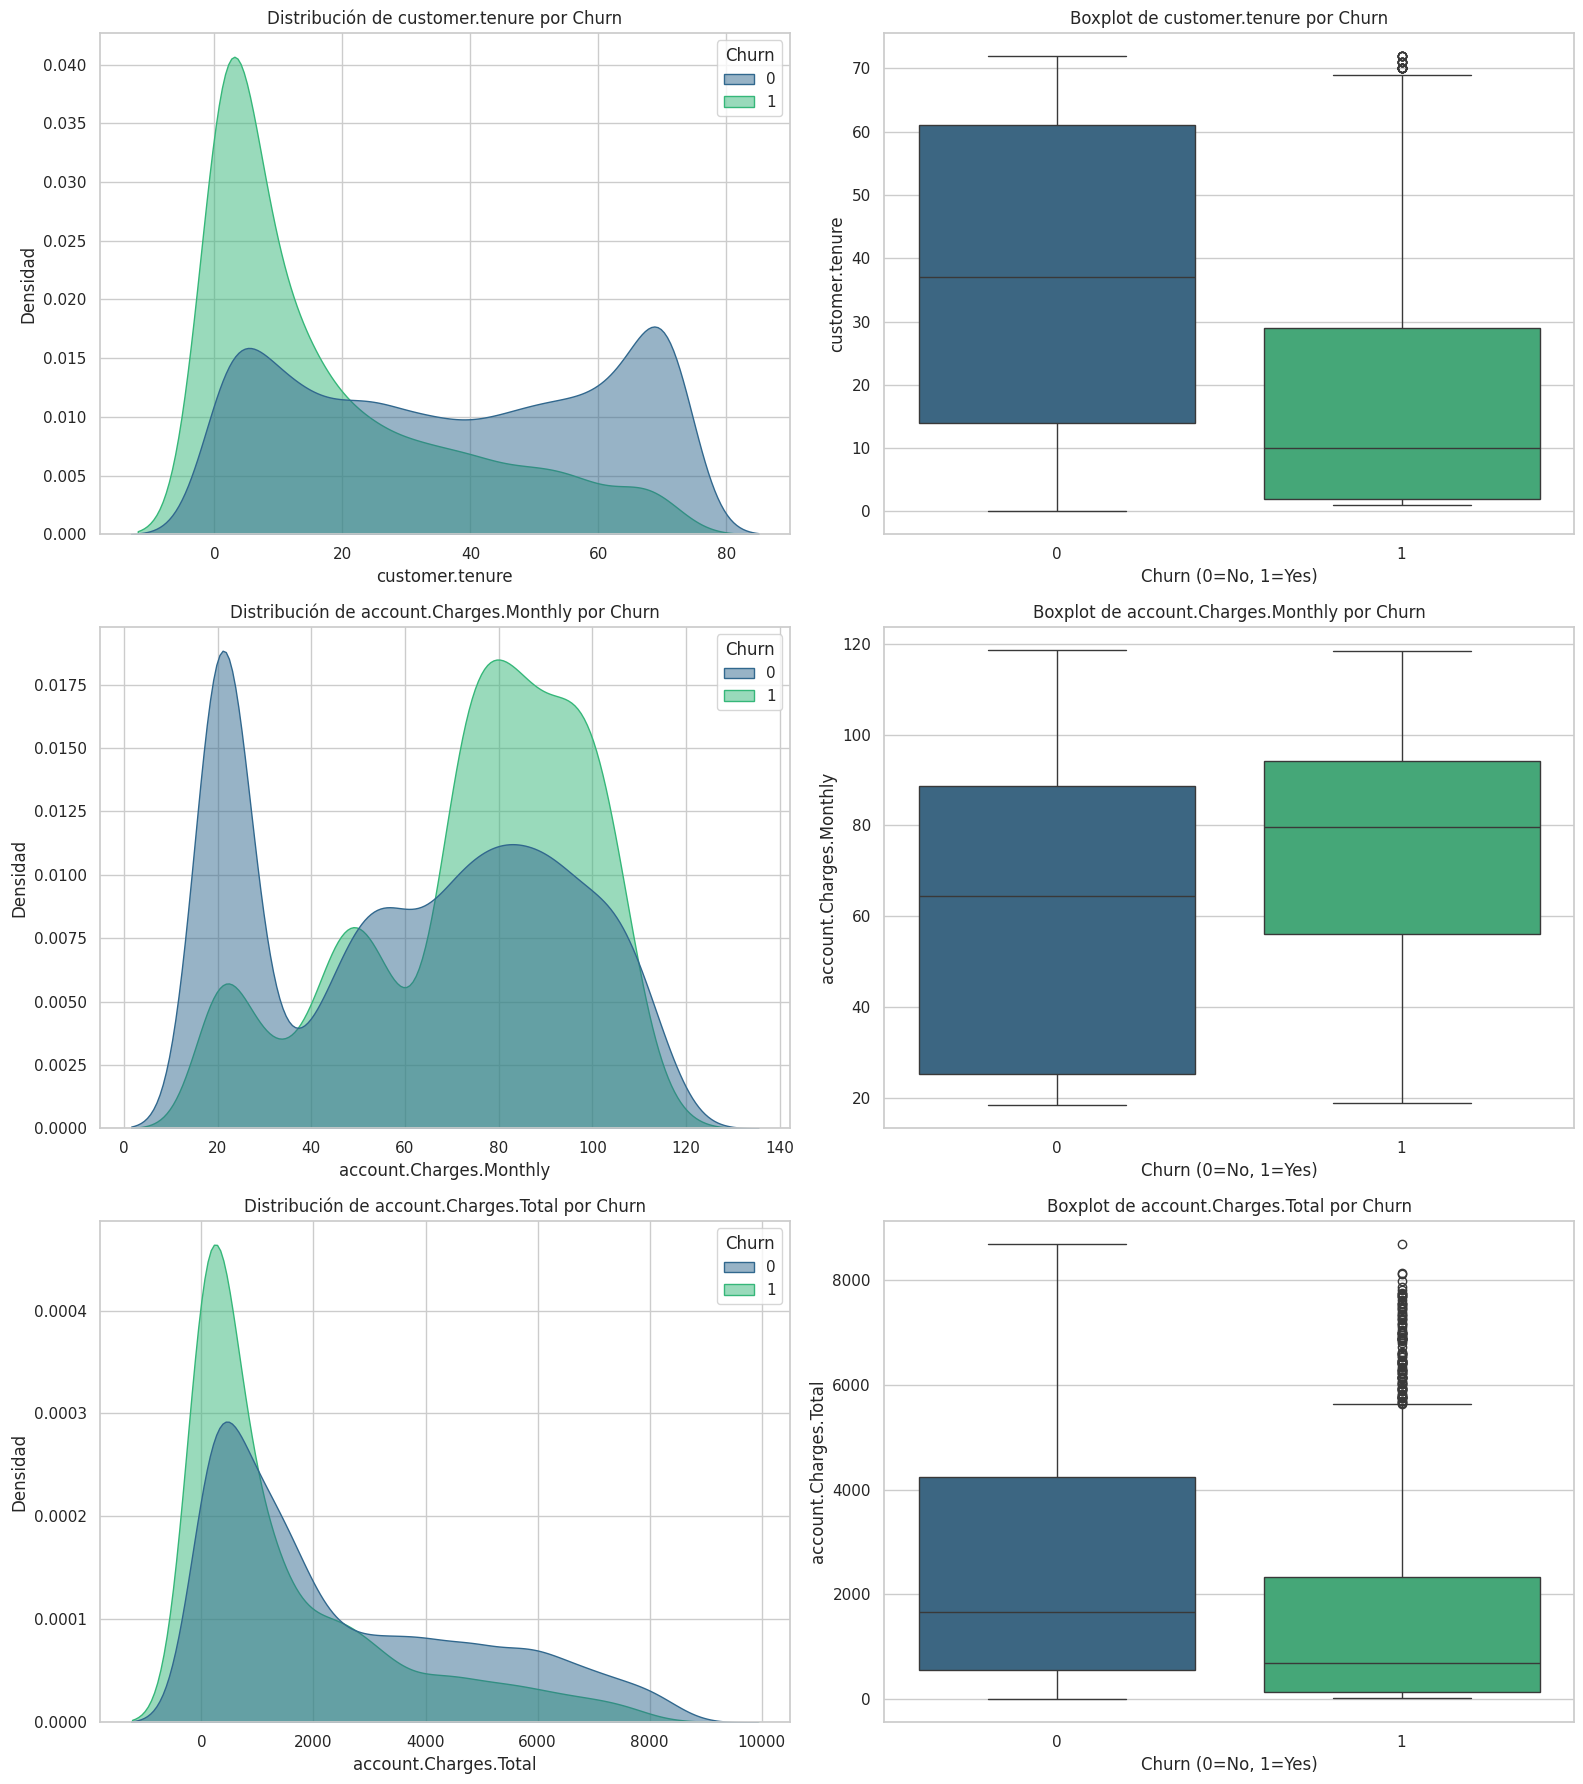

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de seaborn
sns.set_theme(style='whitegrid')

# Crear una figura con 3 filas (una por variable) y 2 columnas (KDE y Boxplot)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))

# Iterar sobre las variables numéricas para generar los gráficos
for i, var in enumerate(numerical_vars):
    # 1. KDE Plot (Distribución)
    sns.kdeplot(data=df, x=var, hue='Churn', fill=True, common_norm=False, ax=axes[i, 0], palette='viridis', alpha=0.5)
    axes[i, 0].set_title(f'Distribución de {var} por Churn')
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel('Densidad')

    # 2. Boxplot (Cuantiles y Outliers)
    # Se asigna hue='Churn' y legend=False para evitar advertencias de versiones futuras
    sns.boxplot(data=df, x='Churn', y=var, hue='Churn', ax=axes[i, 1], palette='viridis', legend=False)
    axes[i, 1].set_title(f'Boxplot de {var} por Churn')
    axes[i, 1].set_xlabel('Churn (0=No, 1=Yes)')
    axes[i, 1].set_ylabel(var)

# Ajustar el diseño para evitar solapamientos
plt.tight_layout()
plt.show()

#📄Informe final

## 1. Introducción

El objetivo de este análisis es identificar y comprender los factores críticos que influyen en la deserción de clientes (**Churn**) de la compañía TelecomX. Utilizando un conjunto de datos en formato JSON que detalla el perfil demográfico, los servicios contratados y los cargos financieros de los usuarios, buscamos extraer hallazgos accionables que permitan mejorar la retención y la toma de decisiones estratégicas.

## 2. Metodología de Limpieza y Transformación de Datos

Para garantizar la calidad y coherencia del análisis, se llevó a cabo un proceso riguroso de limpieza y preparación de los datos:

*   **Normalización de Estructura:** Se transformó el archivo JSON original de TelecomX, el cual presentaba una estructura anidada, a un formato de DataFrame plano utilizando `pd.json_normalize` para facilitar la manipulación tabular.
*   **Corrección de Tipos de Datos:** La columna `account.Charges.Total` se convirtió de tipo objeto a numérico. Los valores no numéricos detectados (espacios en blanco) se transformaron en nulos y posteriormente se imputaron con el valor `0` para mantener la integridad del cálculo.
*   **Tratamiento de Inconsistencias Categóricas:** Se estandarizaron las etiquetas en múltiples columnas de servicios. Específicamente, los valores 'No internet service' y 'No phone service' se unificaron bajo la categoría simple 'No', eliminando redundancias innecesarias para el análisis estadístico.
*   **Ingeniería de Características:**
    *   Se creó la métrica **Cuentas_Diarias**, derivada de la división de los cargos mensuales entre 30 días, permitiendo una visión de consumo a corto plazo.
    *   Se aplicó una **codificación binaria (0/1)** a todas las variables con respuestas 'Yes'/'No' (incluyendo el target 'Churn'), facilitando su uso en futuros modelos predictivos y correlaciones.
*   **Verificación de Calidad:** Se confirmó la ausencia de registros duplicados y se validó la distribución final de los datos transformados.

## 3. Síntesis del Análisis Exploratorio (EDA)

### **Distribución de Evasión (Churn)**
En la muestra analizada, se observa que aproximadamente el **25.7%** de los clientes han abandonado el servicio (Churn = Yes). Esto indica un desequilibrio en las clases, donde la mayoría de los clientes permanecen activos, pero existe un segmento significativo de deserción que requiere atención.

### **Hallazgos en Variables Categóricas**
Al analizar el comportamiento de los clientes según diferentes categorías, se identificaron patrones críticos:
- **Contratos:** Los clientes con contratos de mes a mes (**Month-to-month**) muestran una tasa de abandono significativamente mayor en comparación con aquellos que tienen contratos de uno o dos años.
- **Métodos de Pago:** El uso de **Electronic check** está fuertemente asociado con una mayor probabilidad de Churn, destacándose como el método con mayor deserción entre todas las opciones.
- **Servicios:** Los usuarios de **Fiber optic** también presentan una frecuencia de abandono proporcionalmente más alta que los de DSL o sin servicio de internet.

### **Hallazgos en Variables Numéricas**
Las visualizaciones de distribución (KDE) y los diagramas de caja (Boxplots) revelan tendencias claras:
- **Tenure (Antigüedad):** Existe una relación inversa entre la antigüedad y el Churn; los clientes con **menor tiempo de permanencia** en la empresa tienen una probabilidad mucho más alta de abandonar el servicio.
- **Monthly Charges (Cargos Mensuales):** Los clientes que cancelan su servicio tienden a tener **cargos mensuales más altos** en comparación con los clientes que permanecen. Esto sugiere que el costo del servicio es un factor relevante en la decisión de abandono.
- **Total Charges:** Aunque los cargos totales son menores para quienes abandonan (debido a su baja antigüedad), el flujo de caja perdido por cliente de alto cargo mensual es una métrica de riesgo clave.

## 📈 Informe Final: Conclusiones y Recomendaciones Estratégicas

### **1. Conclusiones e Insights Clave**
Tras realizar un análisis exhaustivo de los datos de TelecomX, se han identificado los siguientes hallazgos críticos que impactan directamente en la tasa de deserción (Churn):

*   **Vulnerabilidad en Contratos de Corto Plazo:** Los clientes con contratos **'Month-to-month'** presentan la mayor tasa de abandono. La falta de un compromiso a largo plazo facilita la salida de clientes ante cualquier insatisfacción o oferta de la competencia.
*   **Riesgo en el Segmento de Fibra Óptica:** A pesar de ser una tecnología avanzada, los usuarios de **Fibra Óptica** muestran una mayor tendencia a la deserción en comparación con DSL. Esto sugiere una posible desconexión entre el alto costo del servicio (Monthly Charges elevados) y la percepción de valor o calidad del soporte técnico.
*   **El 'Periodo Crítico' de Antigüedad (Tenure):** Existe una correlación inversa clara entre la antigüedad y el churn. Los clientes en sus **primeros 6 a 12 meses** son los más propensos a abandonar la compañía, lo que indica deficiencias en el proceso de Onboarding o en la fidelización temprana.
*   **Impacto de Cargos Mensuales:** Los clientes con cargos mensuales superiores al promedio tienen una probabilidad significativamente mayor de cancelar el servicio si no cuentan con servicios adicionales de valor agregado (como soporte técnico o seguridad en línea).

### **2. Recomendaciones Estratégicas**
Basándose en los datos analizados, se proponen las siguientes acciones para mejorar la retención de clientes:

1.  **Programa de Migración de Contratos:**
    *   Implementar una campaña de incentivos (descuentos por 3 meses o upgrades de velocidad gratuitos) para motivar a los clientes de contratos mensuales a migrar a contratos de **1 o 2 años**.

2.  **Optimización de la Propuesta de Valor en Fibra Óptica:**
    *   Realizar una auditoría de calidad en el servicio de fibra óptica y reforzar el **Soporte Técnico Especializado** para este segmento. Considerar la inclusión de servicios de valor agregado (Online Security o Device Protection) sin costo adicional para justificar los cargos mensuales más altos.

3.  **Estrategia de 'Welcome Path' para Nuevos Clientes:**
    *   Diseñar un programa de fidelización específico para clientes con **tenure bajo**. Esto incluye un seguimiento proactivo durante los primeros 90 días, encuestas de satisfacción temprana y ofertas de lealtad al cumplir su primer semestre.

4.  **Promoción de Métodos de Pago Automáticos:**
    *   Dado que los pagos por 'Electronic Check' están asociados a mayor churn, incentivar el registro de **Credit Card o Bank Transfer (Automatic)** mediante pequeños bonos de facturación única para reducir fricciones en el proceso de cobro.